In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df_dt = pd.read_csv(
    "../../results/raisin/raisin_decision_tree.csv"
)

df_knn = pd.read_csv(
    "../../results/raisin/raisin_knn.csv"
)

df_rf = pd.read_csv(
    "../../results/raisin/raisin_random_forest.csv"
)

In [7]:
summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],
    "Mean": [
        df_dt["accuracy_percent"].mean(),
        df_knn["accuracy_percent"].mean(),
        df_rf["accuracy_percent"].mean()
    ],
    "Minimum": [
        df_dt["accuracy_percent"].min(),
        df_knn["accuracy_percent"].min(),
        df_rf["accuracy_percent"].min()
    ],
    "Maximum": [
        df_dt["accuracy_percent"].max(),
        df_knn["accuracy_percent"].max(),
        df_rf["accuracy_percent"].max()
    ],
    "Median": [
        df_dt["accuracy_percent"].median(),
        df_knn["accuracy_percent"].median(),
        df_rf["accuracy_percent"].median()
    ],
    "Std Dev": [
        df_dt["accuracy_percent"].std(),
        df_knn["accuracy_percent"].std(),
        df_rf["accuracy_percent"].std()
    ]
})

summary["Range"] = (
    summary["Maximum"] - summary["Minimum"]
)

summary.round(2)

,Model,Mean,Minimum,Maximum,Median,Std Dev,Range
0,Decision Tree,80.74,75.00,84.44,80.56,2.46,9.44
1,KNN,85.00,81.11,89.44,85.56,2.24,8.33
2,Random Forest,85.85,81.11,90.00,86.11,2.39,8.89


In [8]:
summary.to_csv(
    "../../results/raisin/raisin_model_summary.csv",
    index=False
)

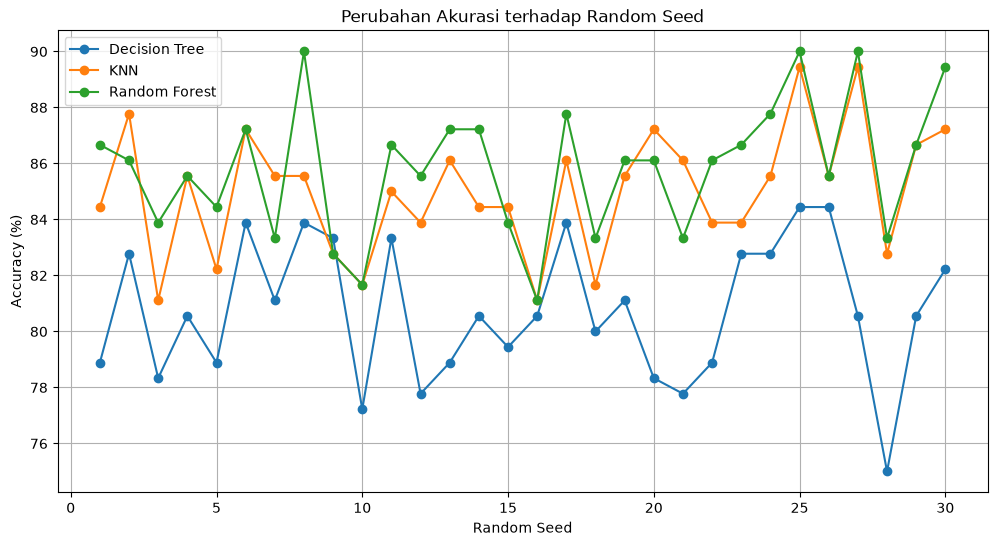

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_dt["seed"],
    df_dt["accuracy_percent"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    df_knn["seed"],
    df_knn["accuracy_percent"],
    marker="o",
    label="KNN"
)

plt.plot(
    df_rf["seed"],
    df_rf["accuracy_percent"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Random Seed")
plt.ylabel("Accuracy (%)")
plt.title("Perubahan Akurasi terhadap Random Seed")
plt.legend()
plt.grid(True)

plt.show()

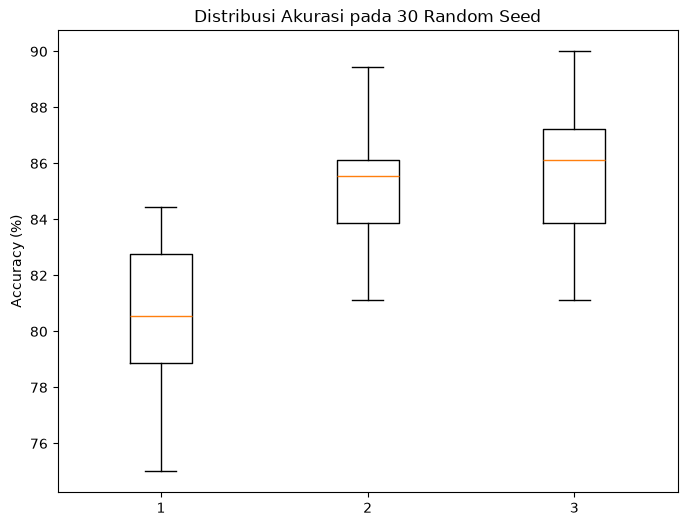

In [10]:
data_boxplot = [
    df_dt["accuracy_percent"],
    df_knn["accuracy_percent"],
    df_rf["accuracy_percent"]
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    data_boxplot,
    label=[
        "Decision Tree",
        "KNN",
        "Random Forest"
    ]
)

plt.ylabel("Accuracy (%)")
plt.title("Distribusi Akurasi pada 30 Random Seed")

plt.show()

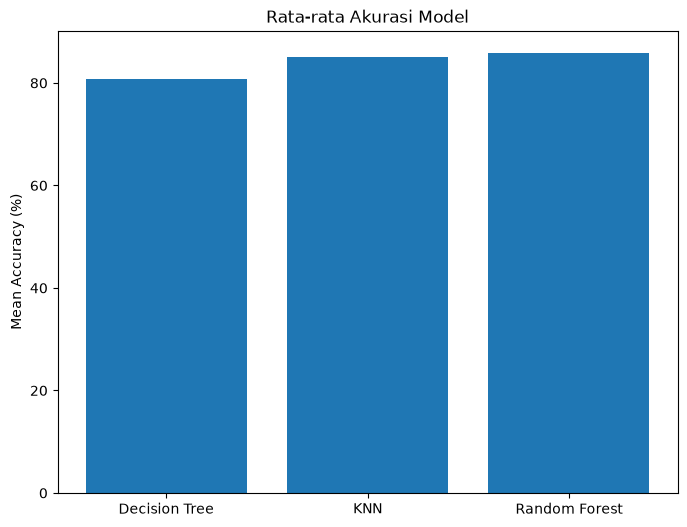

In [11]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Mean"]
)

plt.ylabel("Mean Accuracy (%)")
plt.title("Rata-rata Akurasi Model")

plt.show()

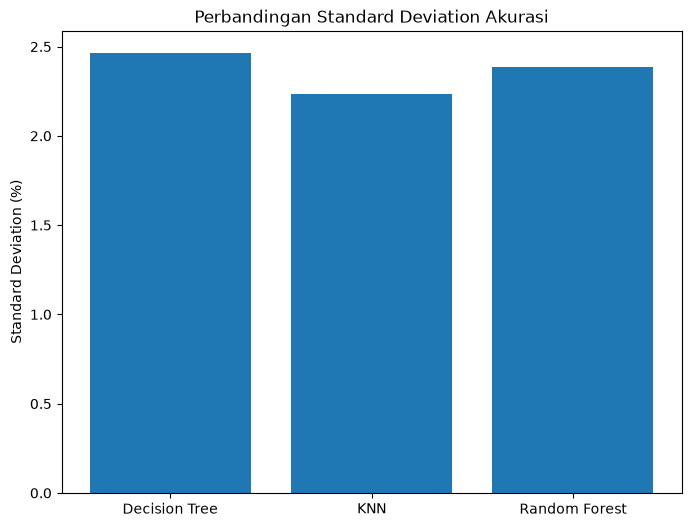

In [12]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Std Dev"]
)

plt.ylabel("Standard Deviation (%)")
plt.title("Perbandingan Standard Deviation Akurasi")

plt.show()

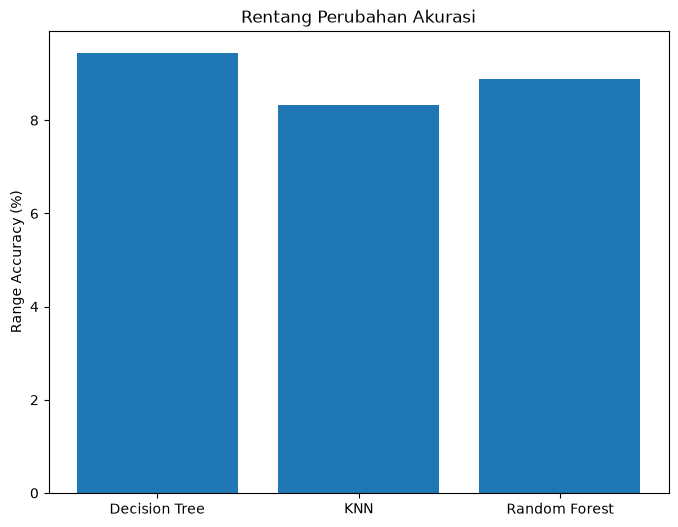

In [13]:
plt.figure(figsize=(8, 6))

plt.bar(
    summary["Model"],
    summary["Range"]
)

plt.ylabel("Range Accuracy (%)")
plt.title("Rentang Perubahan Akurasi")

plt.show()

## Analisis Perbandingan

Berdasarkan 30 variasi random seed, ketiga algoritma menunjukkan tingkat performa dan kestabilan yang berbeda pada Raisin Dataset.

Random Forest memiliki rata-rata akurasi tertinggi, yaitu sekitar 85.85%.

Namun, KNN menunjukkan kestabilan yang sedikit lebih baik berdasarkan nilai standard deviation dan range yang lebih kecil dibandingkan Random Forest.

Decision Tree memiliki rata-rata akurasi terendah dan menunjukkan variasi performa yang lebih besar dibandingkan dua model lainnya.

Hasil ini menunjukkan bahwa model dengan rata-rata akurasi tertinggi tidak selalu menjadi model dengan kestabilan terbaik terhadap perubahan pembagian data training dan testing.